#### Todos

Essential todos:

- Scan plots (just adding cell in this notebook)
- Applying to new / full data

Ideas for simplifying interface (in rough precedence)
- Move parameters that have become standard into defaults (search "todo default"
  in this notebook)
- Simplified reporting plot to display intermediate results
- Choose exposed functions in init.py
- Merge project and model configs. Base model can exist in `base_model` object
  of the project config. Model configs can work exactly the same way they do now
  but drop the `base_model` field from the project config they merge with.
  Removes `setup_base_model` call. Removes need to work with separate configs
  when calibrating.
- Add command line interface for running scan after config setup in notebook.
  With "index" argument for jobarrays
- Keypoint-moseq style "set config" and project_cfg()


### Import modules

In [1]:
%load_ext autoreload
%autoreload 3 --print

In [2]:
from shape_norm.project.paths import Project, create_model
from shape_norm.io import loaders
from shape_norm.models import joint
from shape_norm import config
from shape_norm.models import (
    instantiation,
    setup,
    pose,
    morph,
    util as model_util,
)
from shape_norm import fitting
from shape_norm.fitting import em
from shape_norm.io import alignment, features
from shape_norm.io.armature import Armature
from shape_norm.fitting import methods
from shape_norm.fitting import scans
from shape_norm.pca import fit_with_center, CenteredPCA, PCAData
from shape_norm.io.dataset import PytreeDataset
from shape_norm.io.dataset_refactor import Dataset, SessionMetadata
from shape_norm.models.morph.lowrank_affine import LRAParams, model as lra_model
from shape_norm import pca
from blscale_loader import loader, linear_skeletal as blscale_ls
import os, sys, shutil
import numpy as np
from pprint import pprint
from matplotlib import colors as mpl_col
import jax.numpy as jnp
import itertools as iit
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
import seaborn as sns
from shape_norm import viz
from shape_norm.viz import styles
from scipy.spatial.distance import jensenshannon
from tensorflow_probability.substrates import jax as tfp
from ruamel.yaml import YAML
from bidict import bidict
import matplotlib.pyplot as plt
from collections import defaultdict
import os, re
import tqdm
from cmap import Colormap
import joblib as jl

from pathlib import Path
import logging

logging.getLogger().setLevel(logging.INFO)

#### Project setup

In [3]:
# Directory of .npy files containing keypoint data
data_dir = Path("../../../data_explore/testsets/blscale-arrays")

# Directory for ShapeNorm project
project_dir = Path("../projects/doc-fit-shapenorm")

# Create the project directory if it doesn't exist and create an object to
# manage directories in the ShapeNorm project
project_dir.mkdir(exist_ok=True)
project_paths = Project(project_dir)

In [29]:
# Armature metadata for mouse keypoint data
keypoint_names = [
    "shldr", "back", "hips", "t_base", "t_tip",
    "head", "l_ear", "r_ear", "nose",
    "lr_knee", "lr_foot", "rr_knee", "rr_foot",
    "lf_foot", "rf_foot",
]
keypoint_parents = dict(zip(keypoint_names,
    ["back", "hips", None, "hips", "t_base",
     "shldr", "head", "head", "head",
     "hips", "lr_knee", "hips", "rr_knee",
     "shldr", "shldr"]))


# Set up project.yml
# Defines session names and data sources, body identity for each session,
# metadata defining how to load session data, alignment and feature reduction
# methods to use, and other project-wide settings.
loaders.raw_npy.setup_project_config(
    project_paths.main_config(),
    data_dir,
    feature_type="pcs", # todo defaults
    exclude_keypoints=["t_tip"],
    subsample_to=70, # todo defaults (set to 70 from 700 for testing)
    keypoint_names=keypoint_names,
    keypoint_parents=keypoint_parents,
)

project_cfg = config.load_config(project_paths.main_config())

# Setup base model config in base_model.yml
# Each time a model it created, this config will be copied and the copy will be
# modified
setup.setup_base_model_config(
    project_paths.main_config(), project_paths.base_model_config()
)

Reloading 'shape_norm.project.paths'.
[relative_to] /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/project.yml from /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm  ->  ./project.yml


In [30]:
# todo load_plotter method (wrapper for init_nb) that pulls from config
# todo defaults
plotter, _ = styles.init_nb(
    str(project_paths.root()),
    style="default",
    fmt="pdf",
    display=False,
)

In [31]:
# Load project config and dataset
raw_dataset = loaders.load_dataset(project_cfg["dataset"])

### Calibration

Each component of formatting and the ShapeNorm model needs to
see the data before we can fit.

During this step, the project and base model configuration files will be
modified, and a file `project.calibration.p` will be created in the project
root directory that contains array-typed metadata, e.g. principal component
loadings.

This step will also save figures in a `plots` directory that give details on how
hyperparameters were selected from heuristics for the feature reduction as well
as morph and pose components of the ShapeNorm model.

In [32]:
# todo defaults

# Load uncalibrated project config
project_cfg = config.load_project_config(project_paths.main_config())

# --- Calibration: alignment and feature reduction

project_cfg["features"]["calibration"]["tgt_variance"] = 0.95

# Calibrate alignment and return aligned data
dataset, project_cfg = alignment.sagittal.calibrate(
    raw_dataset, project_cfg, origin="hips", anterior="head"
)

# Calibrate feature reduction and return reduced data
project_cfg = features.pcs.calibrate(dataset, project_cfg)
dataset = features.reduce_to_features(dataset, project_cfg["features"])
config.save_project_config(project_paths.main_config(), project_cfg, write_calib=True)

# --- Calibration: pose and morph models

cfg = config.load_model_config(project_paths.base_model_config())
cfg["morph"]["prior_mode"] = "distance" 
cfg["morph"]["calibration"]["tgt_variance"] = 0.99
cfg["pose"]["calibration"]["n_iter"] = 9
cfg["pose"]["calibration"]["max_components"] = 20
cfg["pose"]["calibration"]["mode"] = "likelihood"
cfg["pose"]["calibration"]["sessions"] = "all"
cfg["pose"]["subj_weight_uniformity"] = 1
cfg["fit"]["n_steps"] = 1000
cfg["fit"]["learning_rate"] = dict(kind="stair", hl=250, lr=5e-1, min=1e-5, factor=1.25)
cfg["fit"]["mstep"]["tol"] = None
cfg["fit"]["update_scales"] = {"pose/*": 1e1}

cfg = pose.gmm.calibrate_base_model(dataset, cfg)
cfg = morph.lowrank_affine.calibrate_base_model(dataset, cfg)
cfg = em.calibrate_base_model(dataset, cfg)
config.save_model_config(project_paths.base_model_config(), cfg, write_calib=True)




Reloading 'shape_norm.models.pose.gmm'.


PosixPath('/Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/pose_calibration.pdf')

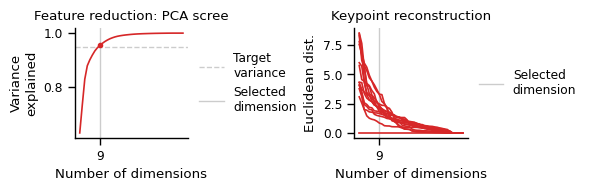

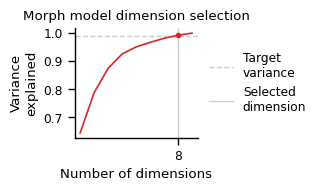

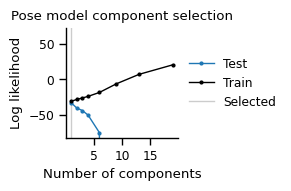

In [34]:
# Plot chosen hyperparameters and heuristics used

cfg = config.load_model_config(project_paths.base_model_config())

fig = features.pcs.plot_calibration(cfg)
plotter.finalize(fig, "feature_calibration")

figs = viz.model.plot_calibration(cfg)
plotter.finalize(figs["morph"], "morph_calibration")
plotter.finalize(figs["pose"], "pose_calibration")

#### Fit models

During this step, a hyperparameter scan is set up and run to test multuple
hyperparameter values. ShapeNorm places a "stiffness" prior on the morph map
that penalizes large differences in body shape, and ShapeNorm's results depend
on the strength of this prior. The scan set up in this section fits ShapeNorm
models with different values of this prior strength.

The `run_scan` function is very computationally intensive and will take several
hours. You can safely rerun the cell that calls `run_scan` without overwriting
previous results, as long as `force_restart` is set to `False`.

In [ ]:
# Todo defaults

scan_name = "stiffness-scan"

# set up parameter scan
scans.setup_scan_config(
    project_paths,
    scan_name,
    {
        "morph.dist_var": np.logspace(-5, 3, 3).tolist(),
        "fit.em.learning_rate.lr": [8e-1] * 3,
        "fit.em.n_steps": [40] * 3,
    },
)

# Prep raw datset for training
# Depending on the parameters of the scan, sessions may be split into parts
scan_dataset, split_meta, _ = scans.prepare_scan_dataset(
    raw_dataset, project_paths, scan_name, return_session_inv=True
)

[relative_to] /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/project.yml from /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/scans/stiffness-scan  ->  ../../project.yml


In [36]:
# Run parameter scan
scans.run_scan(
    project_paths, scan_name, scan_dataset, log_every=20, force_restart=False
)

[relative_to] /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/project.yml from /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/models/stiffness-scan_0  ->  ../../project.yml


INFO:root:Initializing morph model
INFO:root:Initializing pose model
INFO:root:Adjusting learning rate:0.8 -> 0.0004761904761904762
INFO:root:Loading LR schedule: stair
INFO:root:Scaling param: pose/subj_weight_logits,shape (48, 1) by 10.0
INFO:root:Scaling param: pose/pop_weight_logits,shape (1,) by 10.0
INFO:root:Scaling param: pose/means,shape (1, 9) by 10.0
INFO:root:Scaling param: pose/cholesky,shape (1, 45) by 10.0
INFO:root:Unscaled param: morph/_mode_updates, shape (48, 9, 8)
INFO:root:Unscaled param: morph/_offset_updates, shape (48, 9)
INFO:root:Scaling param: pose/subj_weight_logits,shape (48, 1) by 10.0
INFO:root:Scaling param: pose/pop_weight_logits,shape (1,) by 10.0
INFO:root:Scaling param: pose/means,shape (1, 9) by 10.0
INFO:root:Scaling param: pose/cholesky,shape (1, 45) by 10.0
INFO:root:Unscaled param: morph/_mode_updates, shape (48, 9, 8)
INFO:root:Unscaled param: morph/_offset_updates, shape (48, 9)
INFO:root:Step 0 : loss = 5046497968128.0
INFO:root:Step 20 : los

[relative_to] /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/project.yml from /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/models/stiffness-scan_1  ->  ../../project.yml


INFO:root:Initializing morph model
INFO:root:Initializing pose model
INFO:root:Adjusting learning rate:0.8 -> 0.0004761904761904762
INFO:root:Loading LR schedule: stair
INFO:root:Scaling param: pose/subj_weight_logits,shape (48, 1) by 10.0
INFO:root:Scaling param: pose/pop_weight_logits,shape (1,) by 10.0
INFO:root:Scaling param: pose/means,shape (1, 9) by 10.0
INFO:root:Scaling param: pose/cholesky,shape (1, 45) by 10.0
INFO:root:Unscaled param: morph/_mode_updates, shape (48, 9, 8)
INFO:root:Unscaled param: morph/_offset_updates, shape (48, 9)
INFO:root:Scaling param: pose/subj_weight_logits,shape (48, 1) by 10.0
INFO:root:Scaling param: pose/pop_weight_logits,shape (1,) by 10.0
INFO:root:Scaling param: pose/means,shape (1, 9) by 10.0
INFO:root:Scaling param: pose/cholesky,shape (1, 45) by 10.0
INFO:root:Unscaled param: morph/_mode_updates, shape (48, 9, 8)
INFO:root:Unscaled param: morph/_offset_updates, shape (48, 9)
INFO:root:Step 0 : loss = 103310.71875
INFO:root:Step 20 : loss =

[relative_to] /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/project.yml from /Users/kaifox/projects/mph/generative_api/test/projects/doc-fit-shapenorm/models/stiffness-scan_2  ->  ../../project.yml


INFO:root:Initializing morph model
INFO:root:Initializing pose model
INFO:root:Adjusting learning rate:0.8 -> 0.0004761904761904762
INFO:root:Loading LR schedule: stair
INFO:root:Scaling param: pose/subj_weight_logits,shape (48, 1) by 10.0
INFO:root:Scaling param: pose/pop_weight_logits,shape (1,) by 10.0
INFO:root:Scaling param: pose/means,shape (1, 9) by 10.0
INFO:root:Scaling param: pose/cholesky,shape (1, 45) by 10.0
INFO:root:Unscaled param: morph/_mode_updates, shape (48, 9, 8)
INFO:root:Unscaled param: morph/_offset_updates, shape (48, 9)
INFO:root:Scaling param: pose/subj_weight_logits,shape (48, 1) by 10.0
INFO:root:Scaling param: pose/pop_weight_logits,shape (1,) by 10.0
INFO:root:Scaling param: pose/means,shape (1, 9) by 10.0
INFO:root:Scaling param: pose/cholesky,shape (1, 45) by 10.0
INFO:root:Unscaled param: morph/_mode_updates, shape (48, 9, 8)
INFO:root:Unscaled param: morph/_offset_updates, shape (48, 9)
INFO:root:Step 0 : loss = 51594.453125
INFO:root:Step 20 : loss =

### Choose model

In [ ]:
scan_cfg = config.load_config(project_paths.scan(scan_name) / "scan.yml")
models = list(scan_cfg['models'].keys())

100%|██████████| 3/3 [00:00<00:00, 18.94it/s]


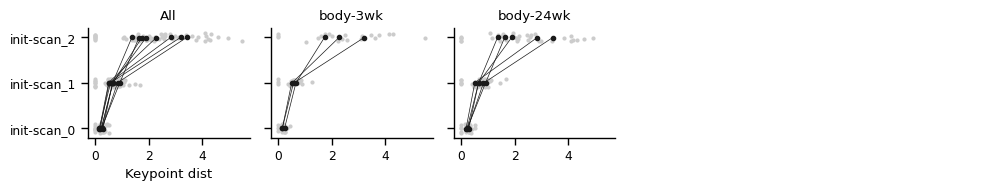

PosixPath('/Users/kaifox/projects/mph/generative_api/test/projects/ont-test/3-24-pose10/scans/morph-prior-scan/plots/reconst_errs.pdf')

In [ ]:
fig = viz.scans.withinbody_induced_errs(project_paths, models, progress = True, dataset=scan_dataset, split_meta=split_meta)
plot_dir = (project_paths.scan('morph-prior-scan') / "plots")
plot_dir.mkdir(exist_ok = True)
plotter.plot_dir = str(plot_dir)
plotter.finalize(fig, "reconst_errs")

Unmorphed: 100%|██████████| 2/2 [00:00<00:00, 161.76it/s]
/Users/kaifox/projects/mph/generative_api/shape_norm/viz/_style.py:89: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


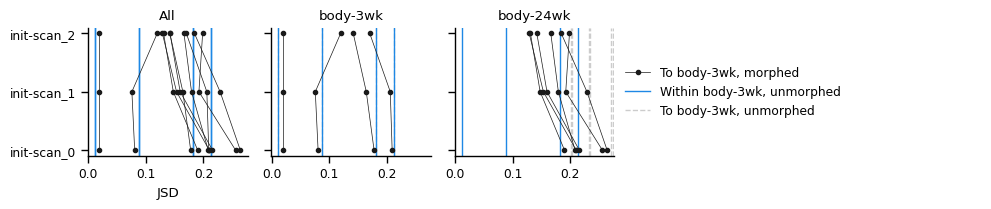

In [ ]:
fig = viz.scans.jsds_to_reference(project_paths, models, progress = True, dataset=scan_dataset, split_meta=split_meta)
ax = fig.get_axes()
plotter.finalize(fig, None)

#### Apply chosen model

A ShapeNorm model can be applied to new data when provided with a filepath or
array of keypoints. In this section, the model selected from the hyperparameter
scan above is applied to the full dataset to generate keypoints normalized to
the reference body.